# Runs Recurrent Neural Network on TAM task

In [1]:
# System imports
from pathlib import Path
import sys

# Plotting imports
import matplotlib.pyplot as plt

# Scientific imports
import numpy as np

# Deeplearning imports
import torch
from torchvision import models, transforms
import neurogym as ngym

# For import from src folder in linux
ROOT = Path().cwd().parent
sys.path.append(str(ROOT))

# Custom imports
from src.task import TAMTask
# from src.networks import CTRNN, RNNNet, train_model, test_model
from src.utils import load_params

## 1. Task environment and dataset

In [6]:
# Get the parameters
task_params = load_params()["Task"]

# Create the environment
TAM_env = TAMTask(sigma=task_params["sigma"], dt=task_params["dt"], cnn=True)
TAM_env.reset(no_step=True)

# Generate a dataset
dataset = ngym.Dataset(TAM_env, batch_size=task_params["batch_size"], seq_len=task_params["sequence_length"])

# Generate one batch of data when called
inputs, target = dataset()
print('Input has shape (SeqLen, Batch, C, W, H) =', inputs.shape)
print('Target has shape (SeqLen, Batch) =', target.shape)
print('Target are the integers, for example target in the first sequence:')
print(target[:, 0])

Input has shape (SeqLen, Batch, C, W, H) = (100, 16, 3, 32, 32)
Target has shape (SeqLen, Batch) = (100, 16)
Target are the integers, for example target in the first sequence:
[0 0 0 0 0 0 2 2 2 2 0 0 0 0 0 0 3 3 3 3 0 0 0 0 0 0 1 1 1 1 0 0 0 0 0 0 3
 3 3 3 0 0 0 0 0 0 2 2 2 2 0 0 0 0 0 0 3 3 3 3 0 0 0 0 0 0 2 2 2 2 0 0 0 0
 0 0 2 2 2 2 0 0 0 0 0 0 1 1 1 1 0 0 0 0 0 0 2 2 2 2]


Ground truth: 0
Time in trial 50 ms


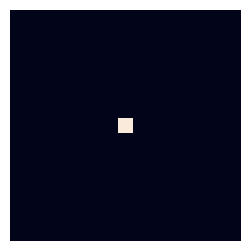

Ground truth: 0
Time in trial 100 ms


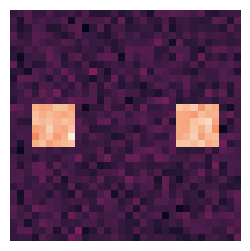

Ground truth: 0
Time in trial 150 ms


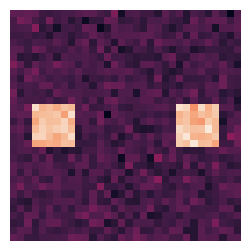

Ground truth: 0
Time in trial 200 ms


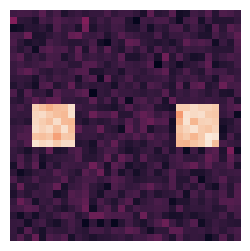

Ground truth: 0
Time in trial 250 ms


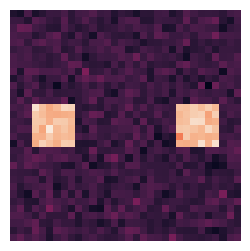

Ground truth: 0
Time in trial 300 ms


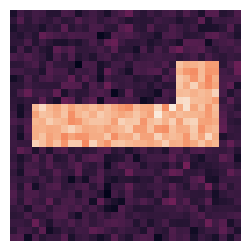

Ground truth: 1
Time in trial 350 ms


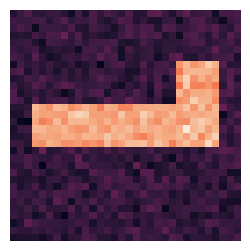

Ground truth: 1
Time in trial 400 ms


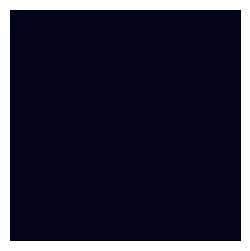

Ground truth: 1
Time in trial 450 ms


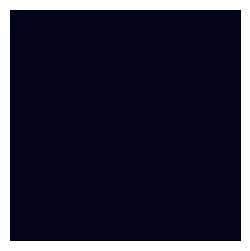

Ground truth: 1
Time in trial 0 ms


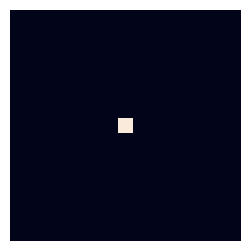

In [24]:
# Visualize the environment
for i in range(10):
    ob, _, _, perf = TAM_env.step(action=0)  # keep choosing action 0
    print(f"Ground truth: {perf['gt']}")
    print('Time in trial {:d} ms'.format(TAM_env.t))
    plt.figure(figsize=(3, 3))
    plt.imshow(ob[0])
    plt.axis('off')
    plt.show()

## 2. Define RNN

In [101]:
# Get parameters
rnn_params = load_params()["RNN"]

# Instantiate the network and print information
input_size = TAM_env.ob.reshape(*TAM_env.ob.shape[:2], -1).shape[-1]
output_size = TAM_env.action_space.n
hidden_size = rnn_params["hidden_size"]

TAM_rnn = RNNNet(
    input_size=input_size,
    hidden_size=hidden_size,
    output_size=output_size,
    dt=TAM_env.dt
)
print(TAM_rnn)

RNNNet(
  (rnn): CTRNN(
    (input2h): Linear(in_features=1024, out_features=128, bias=True)
    (h2h): Linear(in_features=128, out_features=128, bias=True)
  )
  (fc): Linear(in_features=128, out_features=4, bias=True)
)


In [102]:
# Make a cuda device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# device = torch.device("cpu")

TAM_rnn = TAM_rnn.to(device)

## 3. Define CNN

In [3]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [4]:
device

device(type='cuda', index=0)

In [5]:
img_prep = transforms.Compose(
    [
        transforms.ToPILImage('RGB'),
        transforms.Resize(227),
        # transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
        )
    ]
)

cnn = models.alexnet(pretrained=True)
cnn = cnn.to(device)  # gpu

C:\Users\shari\.conda\envs\RNN\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\shari\.conda\envs\RNN\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [6]:
cnn

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [106]:
# Function for feature extraction
layer_features = {}  # stores activations
def hook_layer(name):

    # Hook signature
    def hook(model, act_input, output):
        layer_features[name] = output.detach()
    return hook

# Make hooks for each layer
h1 = cnn.features[3].register_forward_hook(hook_layer("layer2"))
h3 = cnn.features[6].register_forward_hook(hook_layer("layer3"))
h2 = cnn.features[8].register_forward_hook(hook_layer("layer4"))
h4 = cnn.features[10].register_forward_hook(hook_layer("layer5"))

# test
test_img = inputs[0, 10, :, :, :]

# numpy inputs should be (H, W, C)
test_img = np.transpose(test_img, (1, 2, 0))
test_img = img_prep(test_img).unsqueeze(dim=0).to(device)
test = cnn(test_img)

In [68]:
h1.remove()
h2.remove()
h3.remove()
h4.remove()

In [107]:
layer_features["layer2"].shape

torch.Size([1, 192, 27, 27])

In [108]:
layer_features["layer2"].cpu().numpy().flatten().shape

(139968,)

## 4. Train the RNN on task

In [5]:
# Run the model
iter = 500
TAM_rnn = train_model(TAM_rnn, dataset, output_size, device, iter)

Training network...
Step 100, Loss 0.0770, Time 11.6s
Step 200, Loss 0.0004, Time 19.6s
Step 300, Loss 0.0001, Time 29.0s
Step 400, Loss 0.0001, Time 39.0s
Step 500, Loss 0.0000, Time 47.0s


## 5. Save the model

In [6]:
version = 13
save_path = Path().cwd().parent / "data"
model_name = str(save_path / f"rnn_v{version}")

torch.save(TAM_rnn, model_name)
torch.save(TAM_rnn.state_dict(), model_name + "_state_dict")

## 6. Test on new dataset

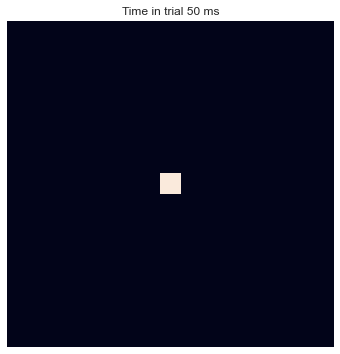

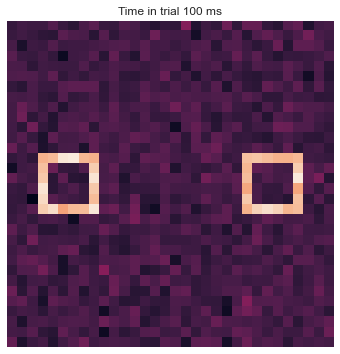

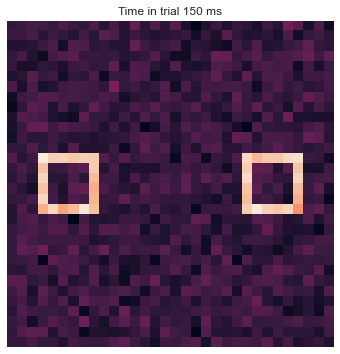

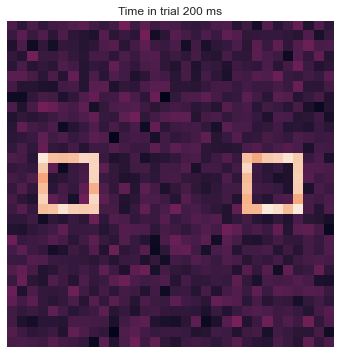

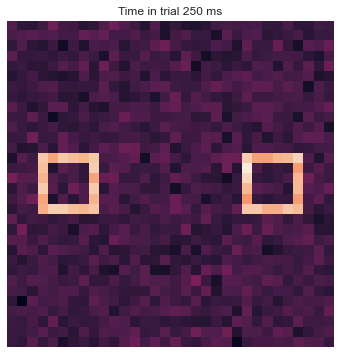

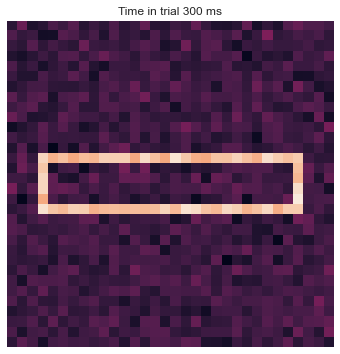

In [14]:
# Create the environment
outline_env = TAMTask(sigma=task_params["sigma"], dt=task_params["dt"], stim_type='outline')
outline_env.reset(no_step=True)

# Visualize the environment
for i in range(10):
    ob, _, _, x = outline_env.step(action=0)  # keep choosing action 0

    if x["gt"] == 0:
        plt.figure(figsize=(6, 6))
        plt.imshow(ob[0])
        plt.title('Time in trial {:d} ms'.format(outline_env.t))
        plt.axis('off')
        plt.show()

In [18]:
# Generate a dataset
outline_dataset = ngym.Dataset(
    outline_env,
    batch_size=task_params["batch_size"],
    seq_len=task_params["sequence_length"]
)

# Generate one batch of data when called
inputs, target = outline_dataset()
print('Input has shape (SeqLen, Batch, Dim) =', inputs.shape)
print('Target has shape (SeqLen, Batch) =', target.shape)
print('Target are the integers, for example target in the first sequence:')
print(target[:, 0])

Input has shape (SeqLen, Batch, Dim) = (100, 16, 1, 32, 32)
Target has shape (SeqLen, Batch) = (100, 16)
Target are the integers, for example target in the first sequence:
[0 0 0 0 0 0 3 3 3 3 0 0 0 0 0 0 2 2 2 2 0 0 0 0 0 0 3 3 3 3 0 0 0 0 0 0 2
 2 2 2 0 0 0 0 0 0 3 3 3 3 0 0 0 0 0 0 3 3 3 3 0 0 0 0 0 0 3 3 3 3 0 0 0 0
 0 0 3 3 3 3 0 0 0 0 0 0 3 3 3 3 0 0 0 0 0 0 1 1 1 1]


In [19]:
# Test the model
n_trials = 1000
trial_infos, activity, perf = test_model(TAM_rnn, outline_dataset, n_trials, device)
print(f"Performance of the network: {perf}")

Performance of the network: 1.0
